# 🛡️ Hệ thống Phát hiện Bất thường với Reinforcement Learning & Autoencoder

Notebook này thực hiện quy trình phát hiện bất thường trên tập dữ liệu MVTec AD sử dụng sự kết hợp giữa:
1. **Autoencoder**: Tái tạo ảnh bình thường.
2. **Predictor (FCN)**: Phân đoạn vùng bất thường từ Residual Map.
3. **RL Agent**: Tối ưu hóa việc lấy mẫu các vùng (patches) quan trọng để huấn luyện.

In [6]:
# 1. Import các thư viện và cấu hình hệ thống
import os
import sys
import torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Thêm thư mục gốc vào path để import các module trong src/
sys.path.append(os.getcwd())

from src.utils import Config
from src.train import train
from src.evaluate import evaluate
Config.EPOCHS = 20
print(f"Thiết bị đang sử dụng: {Config.DEVICE}")
Config.CATEGORY = "bottle" # Thay đổi category tại đây (ví dụ: 'cable', 'capsule', ...)

ImportError: /home/solozy/miniconda3/lib/python3.13/site-packages/cv2/python-3.13/../../../.././libtiff.so.6: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0

## 🏋️ 2. Giai đoạn Huấn luyện (Training)

Trong giai đoạn này, RL Agent sẽ học cách chọn các patch giàu chi tiết và các vùng chưa được khám phá để giúp Autoencoder và Predictor học nhanh hơn.

**Lưu ý**: Để tiết kiệm thời gian chạy thử, bạn có thể chỉnh `Config.EPOCHS` trong `src/utils.py` xuống thấp (ví dụ: 10-20).

In [ ]:
print(f"--- Bắt đầu huấn luyện cho loại: {Config.CATEGORY} ---")
train(Config.CATEGORY)

--- Bắt đầu huấn luyện cho loại: bottle ---
Starting training for bottle on cuda...
Epoch 0/20 | Beta: 1.00 | Reward: 1.0111 | AE Loss: 0.128835 | Pred Loss: 0.277222
Epoch 1/20 | Beta: 0.95 | Reward: 0.9898 | AE Loss: 0.109450 | Pred Loss: 0.264092
Epoch 2/20 | Beta: 0.91 | Reward: 0.9711 | AE Loss: 0.071364 | Pred Loss: 0.246358
Epoch 3/20 | Beta: 0.86 | Reward: 0.9307 | AE Loss: 0.035928 | Pred Loss: 0.210500
Epoch 4/20 | Beta: 0.82 | Reward: 0.8956 | AE Loss: 0.016148 | Pred Loss: 0.143390
Epoch 5/20 | Beta: 0.78 | Reward: 0.8309 | AE Loss: 0.010074 | Pred Loss: 0.063150
Epoch 6/20 | Beta: 0.73 | Reward: 0.7665 | AE Loss: 0.007657 | Pred Loss: 0.017751
Epoch 7/20 | Beta: 0.69 | Reward: 0.7025 | AE Loss: 0.006265 | Pred Loss: 0.005078
Epoch 8/20 | Beta: 0.64 | Reward: 0.6537 | AE Loss: 0.005462 | Pred Loss: 0.002265
Epoch 9/20 | Beta: 0.59 | Reward: 0.6075 | AE Loss: 0.004812 | Pred Loss: 0.001381
Epoch 10/20 | Beta: 0.55 | Reward: 0.5331 | AE Loss: 0.004409 | Pred Loss: 0.000966
Ep

## 📊 3. Giai đoạn Đánh giá (Evaluation)

Chúng ta sẽ đánh giá mô hình trên tập `test`. Các chỉ số chính bao gồm:
- **Pixel-level AUC**: Độ chính xác của bản đồ phân đoạn bất thường.
- **F1-max**: Điểm F1 tốt nhất có thể đạt được tại một ngưỡng (threshold) nhất định.

In [ ]:
print(f"--- Bắt đầu đánh giá cho loại: {CATEGORY} ---")
evaluate(CATEGORY)

--- Bắt đầu đánh giá cho loại: bottle ---
Evaluating category: bottle...
Running inference and collecting results...
Calculating metrics...

--- Metrics for bottle ---
Pixel-level AUC: 0.5286
Pixel-level F1-max: 0.1288
Heatmaps saved to results/ folder.


## 🔍 4. Trực quan hóa kết quả (Review Results)

Dưới đây là các ảnh kết quả từ thư mục `results/`. 
- Cột 1: Ảnh gốc.
- Cột 2: Ground Truth (Vùng lỗi thực tế).
- Cột 3: Predicted Anomaly Map (Dự đoán của mô hình).

Kết quả: bottle_test_0.png


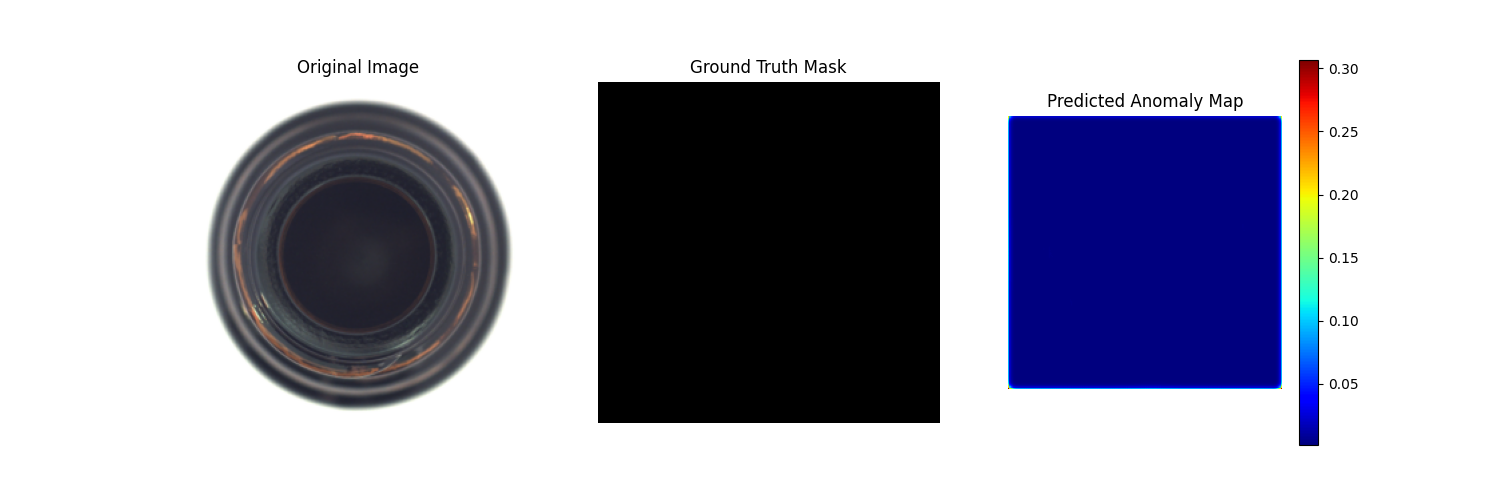

--------------------------------------------------
Kết quả: bottle_test_1.png


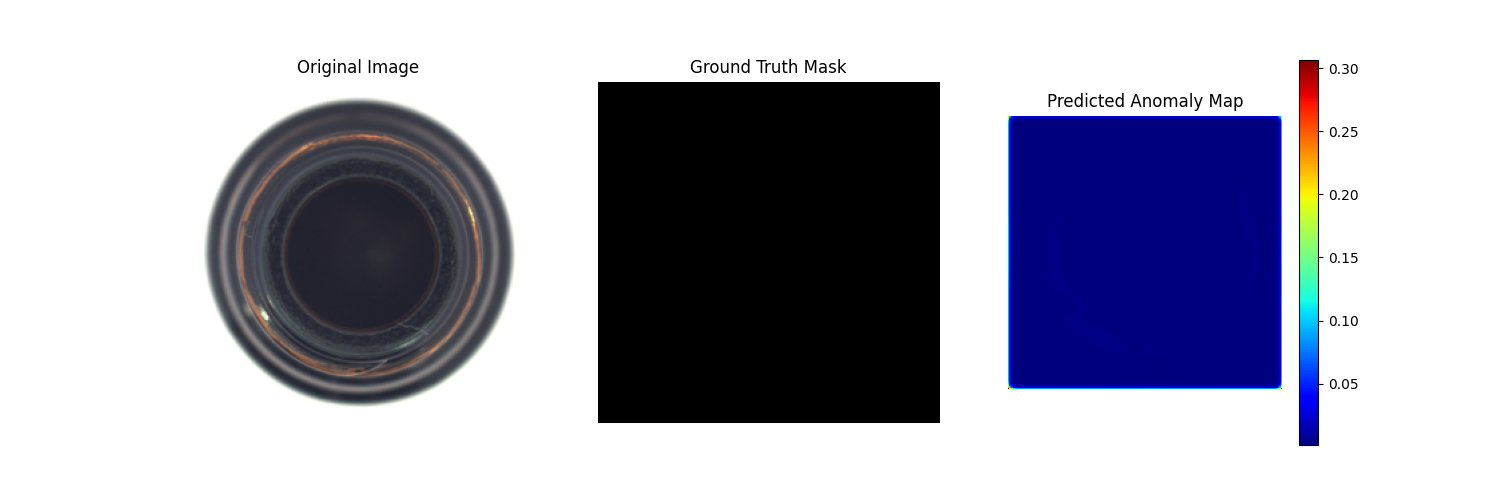

--------------------------------------------------
Kết quả: bottle_test_2.png


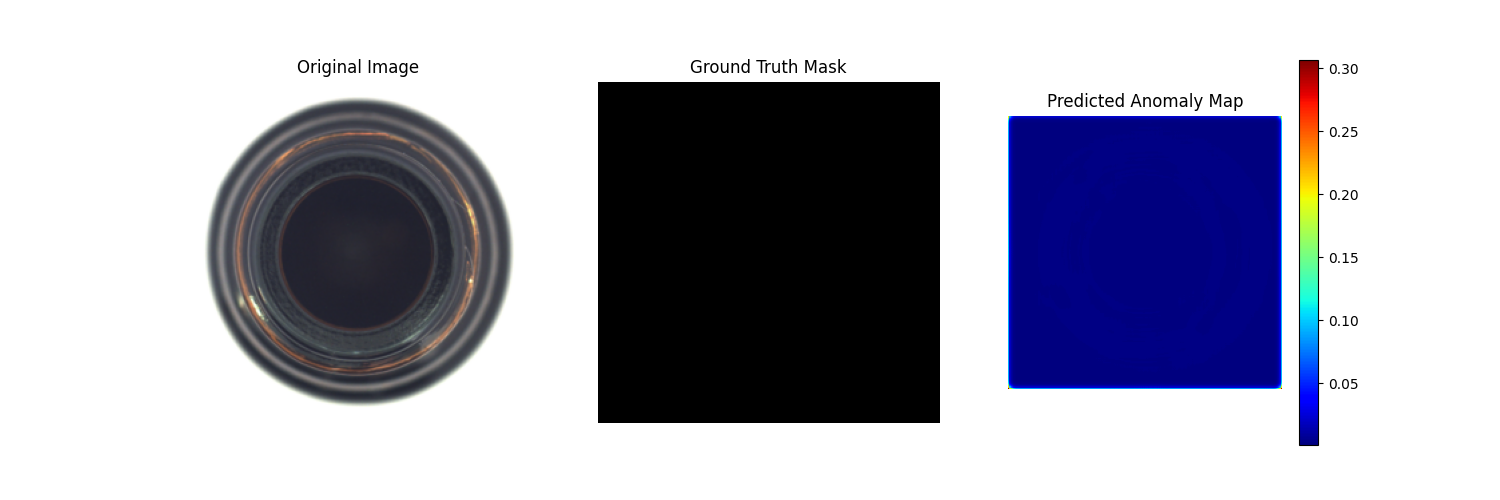

--------------------------------------------------
Kết quả: bottle_test_3.png


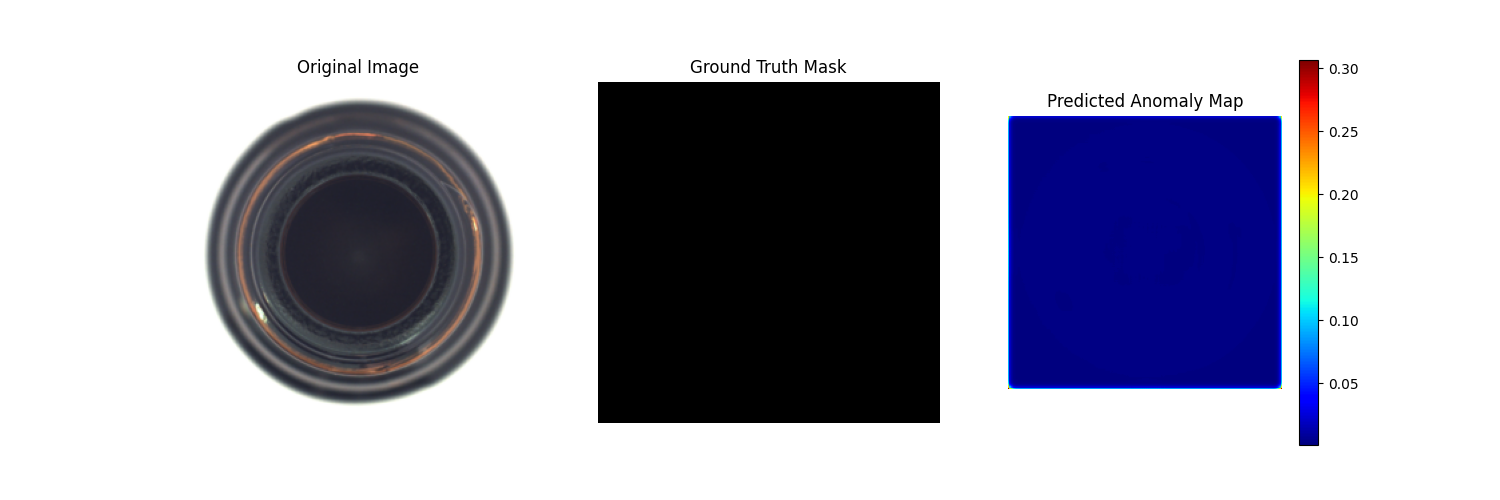

--------------------------------------------------
Kết quả: bottle_test_4.png


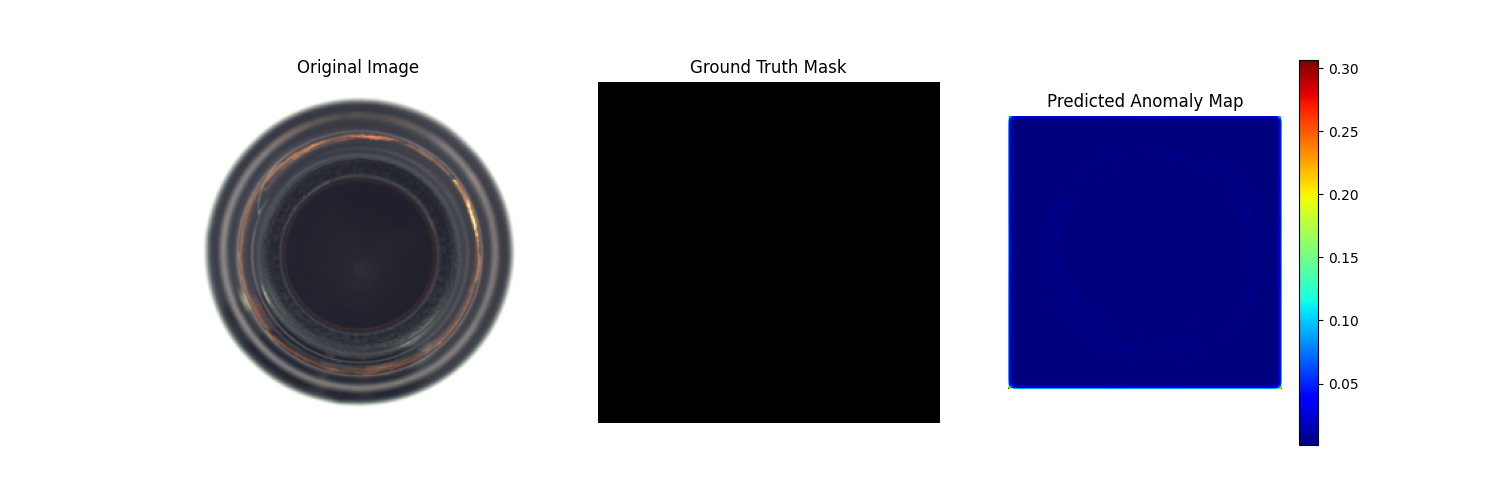

--------------------------------------------------


In [ ]:
result_dir = "results"
images = [f for f in os.listdir(result_dir) if f.startswith(CATEGORY) and f.endswith(".png")]

for img_name in sorted(images):
    print(f"Kết quả: {img_name}")
    display(Image(filename=os.path.join(result_dir, img_name)))
    print("-" * 50)

## 📝 5. Hướng dẫn Review Kết quả

Khi xem xét kết quả, hãy chú ý các điểm sau:
1. **Độ khớp của Heatmap**: Vùng màu đỏ (xác suất cao) trong Predicted Map có khớp với vùng trắng trong Ground Truth không?
2. **Nhiễu (False Positives)**: Các vùng bình thường có bị đánh dấu là bất thường (có màu xanh lá/vàng) không? Nếu có, có thể cần tăng thêm Epoch hoặc điều chỉnh `BETA` trong `Config`.
3. **Chỉ số AUC**: Nếu AUC > 0.90, mô hình đang hoạt động rất tốt ở mức độ pixel.
4. **Chiến lược của RL Agent**: Kiểm tra xem trong quá trình huấn luyện, Reward có tăng dần không. Reward tăng chứng tỏ Agent đã biết chọn các vùng có giá trị thông tin cao hơn.

## 🧪 6. Kiểm thử Toàn diện trên Toàn bộ Ảnh lỗi (Diagnostic All Defects)

Script này sẽ quét qua toàn bộ tập Test, lọc ra chỉ những ảnh có lỗi và hiển thị kết quả chẩn đoán 4 cột để đánh giá chi tiết khả năng phát hiện của mô hình.

In [ ]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
from src.utils import Config, ssim
from src.dataset import MVTecDataset
from src.models import Autoencoder, PredictorFCN
from src.evaluate import post_process

def test_all_defects(category):
    device = torch.device(Config.DEVICE)
    print(f"🚀 Bắt đầu quét TOÀN BỘ ảnh lỗi cho: {category}")
    
    # 1. Load Dataset và chọn toàn bộ ảnh (batch_size=1)
    dataset = MVTecDataset(category, split='test')
    dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
    
    # 2. Load Models
    ae = Autoencoder().to(device)
    predictor = PredictorFCN().to(device)
    ae.load_state_dict(torch.load(f"checkpoints/ae_{category}.pth", map_location=device))
    predictor.load_state_dict(torch.load(f"checkpoints/pred_{category}.pth", map_location=device))
    ae.eval()
    predictor.eval()
    
    output_dir = f"results/{category}_all_defects"
    os.makedirs(output_dir, exist_ok=True)
    
    defect_count = 0
    print("Đang xử lý...")
    
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            label = batch['label'].item()
            
            if label == 1:
                defect_count += 1
                images = batch['image'].to(device)
                
                reconstructed = ae(images)
                res_map = torch.abs(images - reconstructed).mean(dim=1, keepdim=True)
                ssim_val_map = 1.0 - ssim(images, reconstructed, size_average=False)
                pred_map = predictor(res_map)
                
                combined_map = pred_map * ssim_val_map
                combined_np = combined_map[0, 0].cpu().numpy()
                processed_map = post_process(combined_np)
                
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))
                axes[0].imshow(images[0].cpu().permute(1, 2, 0))
                axes[0].set_title(f"Defect Image #{defect_count}")
                
                axes[1].imshow(reconstructed[0].cpu().permute(1, 2, 0))
                axes[1].set_title("AE Reconstruction")
                
                axes[2].imshow(batch['mask'][0, 0], cmap='gray')
                axes[2].set_title("Ground Truth Mask")
                
                axes[3].imshow(processed_map, cmap='jet')
                axes[3].set_title("Detected Anomaly")
                
                for ax in axes: ax.axis('off')
                
                save_path = os.path.join(output_dir, f"defect_{defect_count:03d}.png")
                plt.savefig(save_path)
                plt.close()
                
                if defect_count % 10 == 0:
                    print(f"Đã xử lý {defect_count} ảnh lỗi...")

    print(f"✅ Hoàn tất! Tìm thấy và kiểm thử {defect_count} mẫu lỗi.")
    print(f"📂 Ảnh kết quả lưu tại: {output_dir}")

test_all_defects(CATEGORY)

ImportError: /home/solozy/miniconda3/lib/python3.13/site-packages/cv2/python-3.13/../../../.././libtiff.so.6: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0